<a href="https://colab.research.google.com/github/xiqizheng/chapter4manuscript_NDVILST/blob/main/sentinal_NDVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


shp_path = "/content/drive/MyDrive/point_count/colab/shapefile/lassen_forest_boundary.shp"
boundary = gpd.read_file(shp_path)


csv_path = "/content/drive/MyDrive/point_count/colab/random_points_ndvi_sentinel2_full_2023+2024.csv"
df = pd.read_csv(csv_path)


print(df.columns)


df = df.dropna(subset=["lon", "lat"])

df = df[
    (df["lon"] != 0) &
    (df["lat"] != 0) &
    (df["lon"].between(-125, -115)) &
    (df["lat"].between(35, 45))
].copy()

print("points:", len(df))


gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)


gdf_points = gdf_points.to_crs(boundary.crs)

print("boundary CRS:", boundary.crs)
print("points CRS:", gdf_points.crs)


print("Boundary bounds:", boundary.total_bounds)
print("Points bounds:", gdf_points.total_bounds)

Index(['year', 'nest', 'lon', 'lat', 'dist_m', 'rand_id',
       'NDVImaxComposite_bufMean_50m', 'original_ndvi', 'ndvi_2023_sentinel2',
       'delta2023', 'expected_replacement_ndvi_2023', 'original_ndvi_24',
       'ndvi_2024_sentinel2', 'delta', 'nextbest',
       'expected_replacement_ndvi_2024'],
      dtype='object')
points: 1410
boundary CRS: EPSG:3310
points CRS: EPSG:3310
Boundary bounds: [-162832.0937  184714.25    -48256.9375  324518.    ]
Points bounds: [-187636.22518859   55299.8879321   -67852.88774357  290431.49056907]


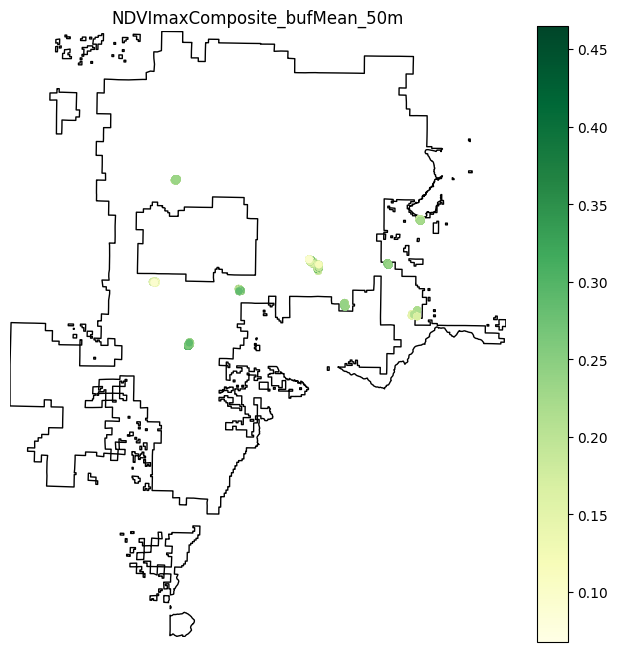

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))


boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)


gdf_points.plot(
    ax=ax,
    column="NDVImaxComposite_bufMean_50m",
    cmap="YlGn",
    legend=True,
    markersize=20
)


xmin, ymin, xmax, ymax = boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title("NDVImaxComposite_bufMean_50m")
ax.set_axis_off()
plt.show()

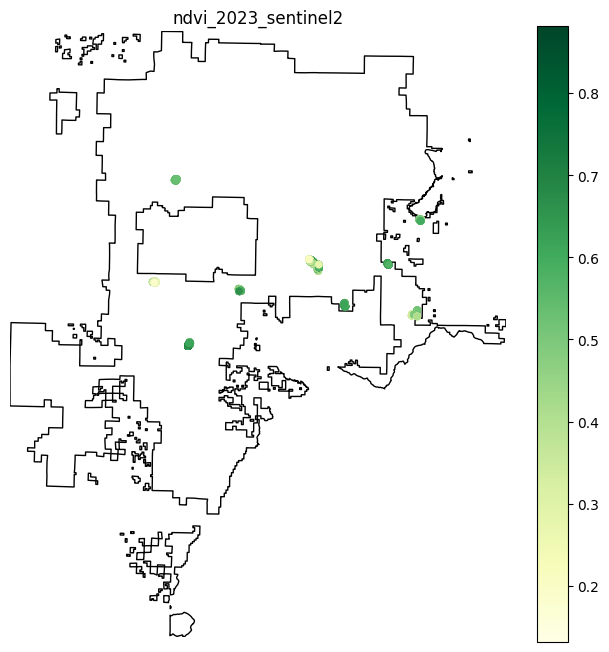

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))


boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)


gdf_points.plot(
    ax=ax,
    column="ndvi_2023_sentinel2",
    cmap="YlGn",
    legend=True,
    markersize=20
)


xmin, ymin, xmax, ymax = boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title("ndvi_2023_sentinel2")
ax.set_axis_off()
plt.show()

object
float64
NaN count: 10


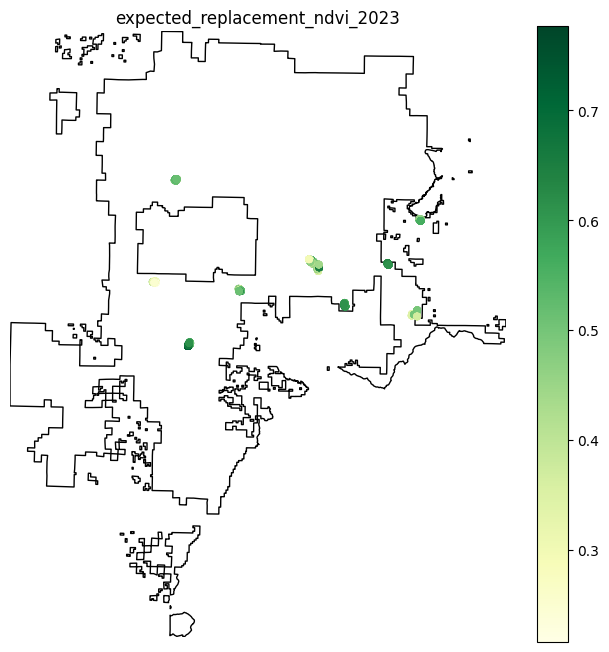

In [ ]:
col = "expected_replacement_ndvi_2023"


print(gdf_points[col].dtype)


gdf_points[col] = pd.to_numeric(gdf_points[col], errors="coerce")


print(gdf_points[col].dtype)


print("NaN count:", gdf_points[col].isna().sum())

plot_gdf = gdf_points.dropna(subset=[col]).copy()

fig, ax = plt.subplots(figsize=(8, 8))

boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)

plot_gdf.plot(
    ax=ax,
    column=col,
    cmap="YlGn",
    legend=True,
    markersize=20
)

xmin, ymin, xmax, ymax = boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(col)
ax.set_axis_off()
plt.show()

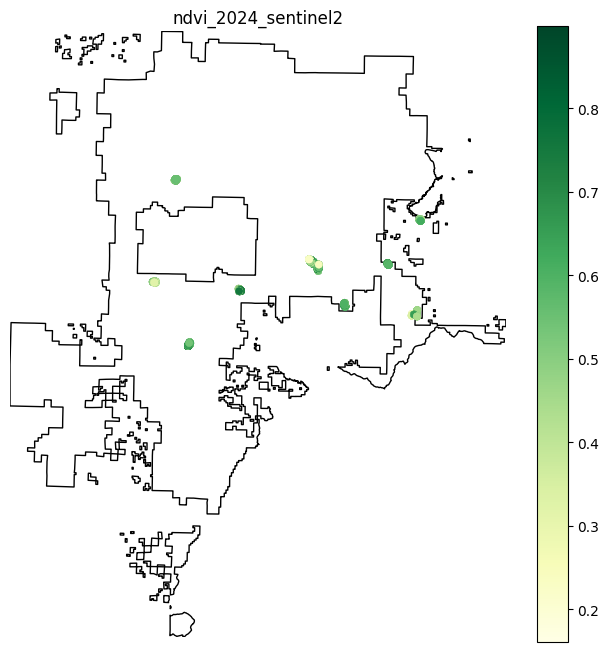

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))


boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)


gdf_points.plot(
    ax=ax,
    column="ndvi_2024_sentinel2",
    cmap="YlGn",
    legend=True,
    markersize=20
)


xmin, ymin, xmax, ymax = boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title("ndvi_2024_sentinel2")
ax.set_axis_off()
plt.show()

object
float64
NaN count: 10


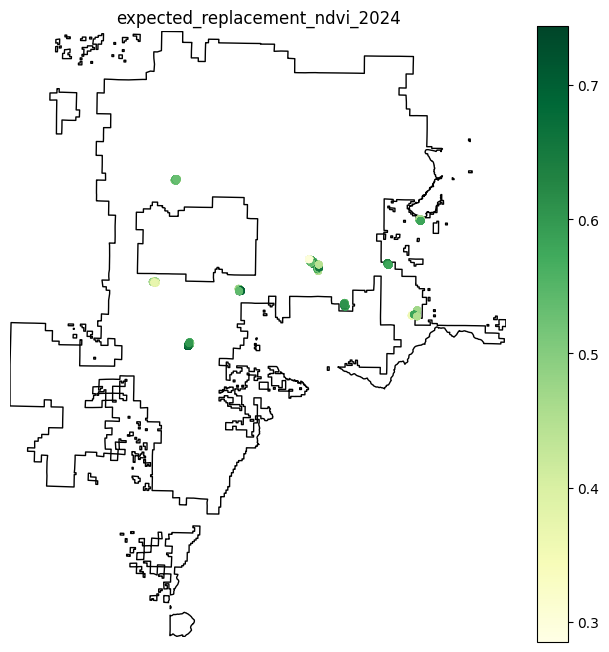

In [ ]:
col = "expected_replacement_ndvi_2024"


print(gdf_points[col].dtype)


gdf_points[col] = pd.to_numeric(gdf_points[col], errors="coerce")


print(gdf_points[col].dtype)


print("NaN count:", gdf_points[col].isna().sum())

plot_gdf = gdf_points.dropna(subset=[col]).copy()

fig, ax = plt.subplots(figsize=(8, 8))

boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)

plot_gdf.plot(
    ax=ax,
    column=col,
    cmap="YlGn",
    legend=True,
    markersize=20
)

xmin, ymin, xmax, ymax = boundary.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_title(col)
ax.set_axis_off()
plt.show()

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask
from rasterio.io import MemoryFile
from rasterio.merge import merge
from rasterio.plot import show

# ========= path =========
shp_path = "/content/drive/MyDrive/point_count/colab/shapefile/lassen_forest_boundary.shp"

# Scene up
red1_path = "/content/drive/MyDrive/point_count/colab/sentinal2023_10m/upper_B04_10m.jp2"
nir1_path = "/content/drive/MyDrive/point_count/colab/sentinal2023_10m/upper_B08_10m.jp2"

# Scene down
red2_path = "/content/drive/MyDrive/point_count/colab/sentinal2023_10m/down_B04_10m.jp2"
nir2_path = "/content/drive/MyDrive/point_count/colab/sentinal2023_10m/down_B08_10m.jp2"

# ========= read boundary =========
boundary = gpd.read_file(shp_path)

# ========= function: clip -> NDVI =========
def clip_ndvi_to_mem(red_path, nir_path, boundary):
    with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
        boundary_proj = boundary.to_crs(red_src.crs)

        # clip
        red_clip, transform = mask(red_src, boundary_proj.geometry, crop=True, filled=False)
        nir_clip, _ = mask(nir_src, boundary_proj.geometry, crop=True, filled=False)

        red = red_clip[0].astype("float32")
        nir = nir_clip[0].astype("float32")

        # NDVI
        np.seterr(divide="ignore", invalid="ignore")
        ndvi = (nir - red) / (nir + red)

        # set N/A outside of mask
        ndvi = np.where(red.mask | nir.mask, np.nan, ndvi)

        # remove abnormal value
        ndvi[(ndvi < -1) | (ndvi > 1)] = np.nan

        meta = red_src.meta.copy()
        meta.update({
            "driver": "GTiff",
            "height": ndvi.shape[0],
            "width": ndvi.shape[1],
            "transform": transform,
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan
        })

        memfile = MemoryFile()
        with memfile.open(**meta) as dst:
            dst.write(ndvi.astype("float32"), 1)

        return memfile

# ========= two clipped NDVI =========
ndvi_mem1 = clip_ndvi_to_mem(red1_path, nir1_path, boundary)
ndvi_mem2 = clip_ndvi_to_mem(red2_path, nir2_path, boundary)

src1 = ndvi_mem1.open()
src2 = ndvi_mem2.open()

# ========= mosaic to same grid =========
mosaic_first, out_transform = merge([src1, src2])

# ========= overlapped region average NDVI =========
arr1 = np.full((mosaic_first.shape[1], mosaic_first.shape[2]), np.nan, dtype="float32")
arr2 = np.full((mosaic_first.shape[1], mosaic_first.shape[2]), np.nan, dtype="float32")

# merge two graph to one grid
m1, _ = merge([src1], bounds=None, res=src1.res)
m2, _ = merge([src2], bounds=None, res=src2.res)

# merge to same output scale
from rasterio.warp import reproject, Resampling

reproject(
    source=rasterio.band(src1, 1),
    destination=arr1,
    src_transform=src1.transform,
    src_crs=src1.crs,
    dst_transform=out_transform,
    dst_crs=src1.crs,
    resampling=Resampling.nearest,
    dst_nodata=np.nan
)

reproject(
    source=rasterio.band(src2, 1),
    destination=arr2,
    src_transform=src2.transform,
    src_crs=src2.crs,
    dst_transform=out_transform,
    dst_crs=src2.crs,
    resampling=Resampling.nearest,
    dst_nodata=np.nan
)

# ========= overlap average =========
ndvi_mean = np.nanmean(np.stack([arr1, arr2]), axis=0)

# ========= plot =========
fig, ax = plt.subplots(figsize=(8, 8))

show(
    ndvi_mean,
    transform=out_transform,
    ax=ax,
    cmap="YlGn",
    vmin=0,
    vmax=0.8
)

boundary_proj = boundary.to_crs(src1.crs)
boundary_proj.boundary.plot(ax=ax, color="black", linewidth=1)

ax.set_title("Sentinel-2 NDVI Mosaic (Mean Composite, 2023)")
ax.set_axis_off()
plt.show()